# MLP for Regression on Synthetic Data

---

## Learning Objectives

By the end of this notebook, you will:

- Generate synthetic regression datasets with noise and outliers
- Build a multi-layer perceptron (MLP) for regression using `nn.Module`
- Train the MLP with MSE, MAE, and Huber losses
- Understand how outliers affect different loss functions
- Plot predictions vs ground truth and training curves

## Prerequisites

- **DL100**: Neural network fundamentals (forward pass, backpropagation)
- **DL150**: PyTorch foundations (`nn.Module`, optimizers, tensors)
- Basic understanding of regression problems

## Table of Contents

1. [Setup and Imports](#1.-Setup-and-Imports)
2. [Generate Synthetic Regression Data](#2.-Generate-Synthetic-Regression-Data)
3. [Visualize the Data](#3.-Visualize-the-Data)
4. [Build the MLP for Regression](#4.-Build-the-MLP-for-Regression)
5. [Training Loop with MSE Loss](#5.-Training-Loop-with-MSE-Loss)
6. [Predictions vs Ground Truth](#6.-Predictions-vs-Ground-Truth)
7. [Outliers: MSE vs MAE vs Huber](#7.-Outliers:-MSE-vs-MAE-vs-Huber)
8. [Training Curves Comparison](#8.-Training-Curves-Comparison)
9. [Common Mistakes and Debugging Tips](#9.-Common-Mistakes-and-Debugging-Tips)
10. [Exercises](#10.-Exercises)

---

## 1. Setup and Imports

In [1]:
import sys
sys.path.insert(0, "../..")
from src.utils.seed import set_global_seed
from src.utils.device import get_device
from src.utils.plotting import plot_loss_curves

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

set_global_seed(42)
device = get_device()

print("Setup complete.")

Using GPU: NVIDIA GeForce RTX 4090 Laptop GPU
Setup complete.


---

## 2. Generate Synthetic Regression Data

We use `sklearn.datasets.make_regression` to create a dataset with a known linear relationship,
then add Gaussian noise to make it realistic.

The true model is:

$$y = X \mathbf{w} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

In [2]:
set_global_seed(42)

# Generate data: 1000 samples, 1 feature (for easy visualization)
X, y, true_coef = make_regression(
    n_samples=1000,
    n_features=1,
    noise=15.0,
    coef=True,
    random_state=42,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"True coefficient: {true_coef:.3f}")

X shape: (1000, 1)
y shape: (1000,)
True coefficient: 16.748


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (fit on train only!)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize targets for better training
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"Train: {X_train_scaled.shape[0]} samples")
print(f"Test:  {X_test_scaled.shape[0]} samples")

Train: 800 samples
Test:  200 samples


In [4]:
# Convert to PyTorch tensors and create DataLoaders
def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=64):
    """Create train and test DataLoaders from numpy arrays."""
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    test_ds = TensorDataset(
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(y_te, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)
    return train_loader, test_loader

train_loader, test_loader = make_loaders(
    X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled
)
print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 13


---

## 3. Visualize the Data

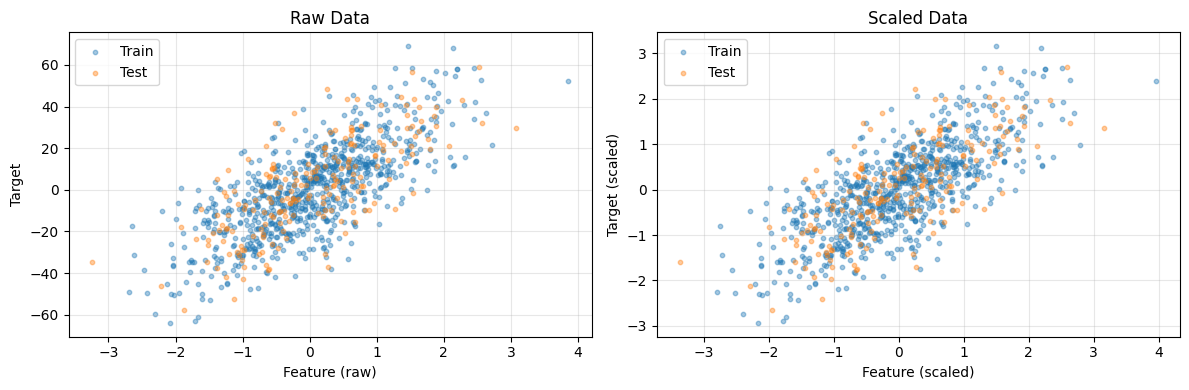

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw data
axes[0].scatter(X_train[:, 0], y_train, alpha=0.4, s=10, label="Train")
axes[0].scatter(X_test[:, 0], y_test, alpha=0.4, s=10, label="Test")
axes[0].set_xlabel("Feature (raw)")
axes[0].set_ylabel("Target")
axes[0].set_title("Raw Data")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scaled data
axes[1].scatter(X_train_scaled[:, 0], y_train_scaled, alpha=0.4, s=10, label="Train")
axes[1].scatter(X_test_scaled[:, 0], y_test_scaled, alpha=0.4, s=10, label="Test")
axes[1].set_xlabel("Feature (scaled)")
axes[1].set_ylabel("Target (scaled)")
axes[1].set_title("Scaled Data")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 4. Build the MLP for Regression

Our architecture:

$$\text{Input}(1) \to \text{Linear}(64) \to \text{ReLU} \to \text{Linear}(32) \to \text{ReLU} \to \text{Linear}(16) \to \text{ReLU} \to \text{Linear}(1)$$

For regression, the output layer has **no activation function** -- we want unbounded predictions.

In [6]:
class RegressionMLP(nn.Module):
    """Multi-layer perceptron for regression."""

    def __init__(self, input_dim, hidden_dims=(64, 32, 16)):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))  # single output for regression
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)  # (batch,) instead of (batch, 1)


# Instantiate and inspect
model = RegressionMLP(input_dim=1).to(device)
print(model)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")

RegressionMLP(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 2,753


---

## 5. Training Loop with MSE Loss

Mean Squared Error (MSE) is the most common loss for regression:

$$\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

In [13]:
def train_regression_model(model, train_loader, test_loader, loss_fn,
                           lr=1e-3, epochs=100, device=device, verbose=True):
    """Train a regression model and return history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # optimizer = torch.opotim.gradient.momentum(model.parameters(), lr=lr, momentum=0.9)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        # -- Training --
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # -- Validation --
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                val_losses.append(loss_fn(preds, y_batch).item())

        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    return history

In [14]:
set_global_seed(42)
model_mse = RegressionMLP(input_dim=1).to(device)
loss_mse = nn.MSELoss()

history_mse = train_regression_model(
    model_mse, train_loader, test_loader,
    loss_fn=loss_mse, lr=1e-3, epochs=100
)

Epoch   1/100 | Train Loss: 1.0394 | Val Loss: 0.9065
Epoch  20/100 | Train Loss: 0.4583 | Val Loss: 0.5184
Epoch  40/100 | Train Loss: 0.4507 | Val Loss: 0.5138
Epoch  60/100 | Train Loss: 0.4473 | Val Loss: 0.5173
Epoch  80/100 | Train Loss: 0.4555 | Val Loss: 0.5171
Epoch 100/100 | Train Loss: 0.4510 | Val Loss: 0.5177


In [ ]:
plot_loss_curves(history_mse, title="MSE Training Curves")

---

## 6. Predictions vs Ground Truth

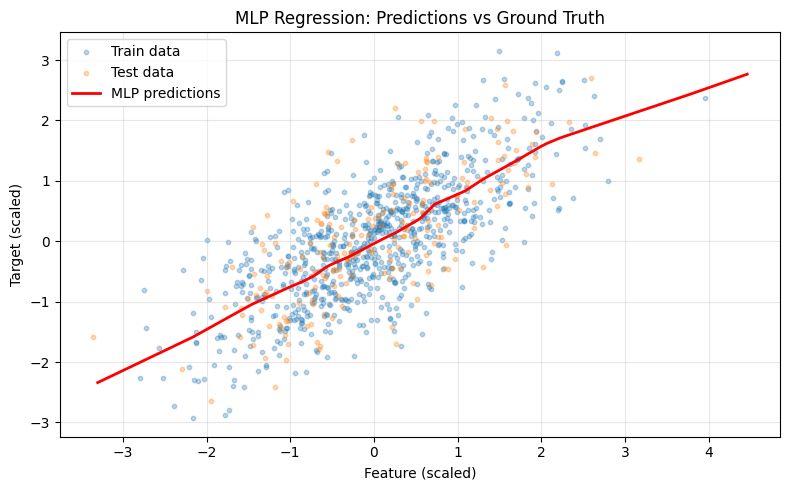

In [15]:
@torch.no_grad()
def get_predictions(model, X_np, device=device):
    """Get model predictions as numpy array."""
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
    return model(X_t).cpu().numpy()


# Generate a fine grid for smooth prediction curve
X_grid = np.linspace(X_train_scaled.min() - 0.5, X_train_scaled.max() + 0.5, 300).reshape(-1, 1)
y_pred_grid = get_predictions(model_mse, X_grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_scaled[:, 0], y_train_scaled, alpha=0.3, s=10, label="Train data")
ax.scatter(X_test_scaled[:, 0], y_test_scaled, alpha=0.3, s=10, label="Test data")
ax.plot(X_grid[:, 0], y_pred_grid, color="red", linewidth=2, label="MLP predictions")
ax.set_xlabel("Feature (scaled)")
ax.set_ylabel("Target (scaled)")
ax.set_title("MLP Regression: Predictions vs Ground Truth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

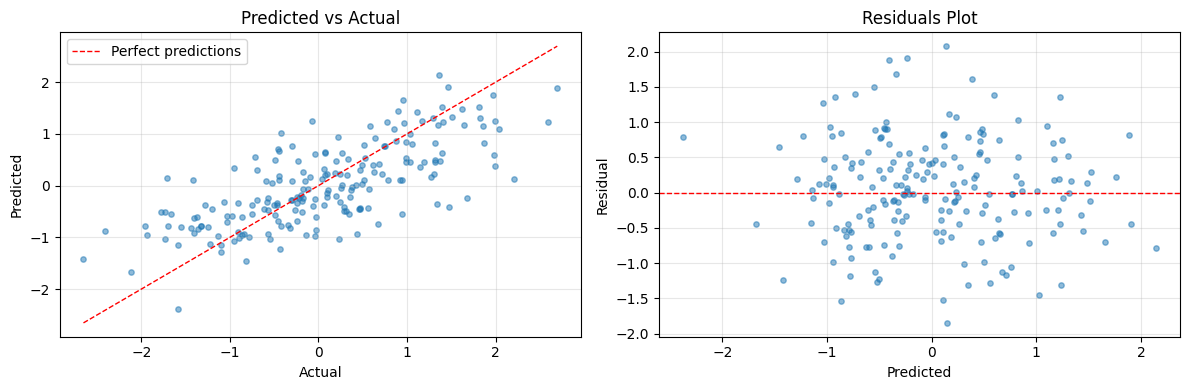

Test MSE:  0.5091
Test MAE:  0.5601
Test R^2:  0.5248


In [16]:
# Residual plot
y_pred_test = get_predictions(model_mse, X_test_scaled)
residuals = y_test_scaled - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs Actual
axes[0].scatter(y_test_scaled, y_pred_test, alpha=0.5, s=15)
lims = [min(y_test_scaled.min(), y_pred_test.min()), max(y_test_scaled.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect predictions")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(f"Test MSE:  {mean_squared_error(y_test_scaled, y_pred_test):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test_scaled, y_pred_test):.4f}")
print(f"Test R^2:  {r2_score(y_test_scaled, y_pred_test):.4f}")

---

## 7. Outliers: MSE vs MAE vs Huber

Outliers can dramatically affect training. Let's compare three loss functions:

**MSE (L2 Loss):**
$$\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

- Squares errors, so outliers have **quadratically more influence**

**MAE (L1 Loss):**
$$\mathcal{L}_{\text{MAE}} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

- Linear penalty, more **robust to outliers**
- Gradient is constant (not smooth at zero)

**Huber Loss (Smooth L1):**
$$\mathcal{L}_{\text{Huber}} = \begin{cases} \frac{1}{2}(y_i - \hat{y}_i)^2 & \text{if } |y_i - \hat{y}_i| \le \delta \\ \delta |y_i - \hat{y}_i| - \frac{1}{2}\delta^2 & \text{otherwise} \end{cases}$$

- **Best of both worlds**: quadratic for small errors, linear for large errors

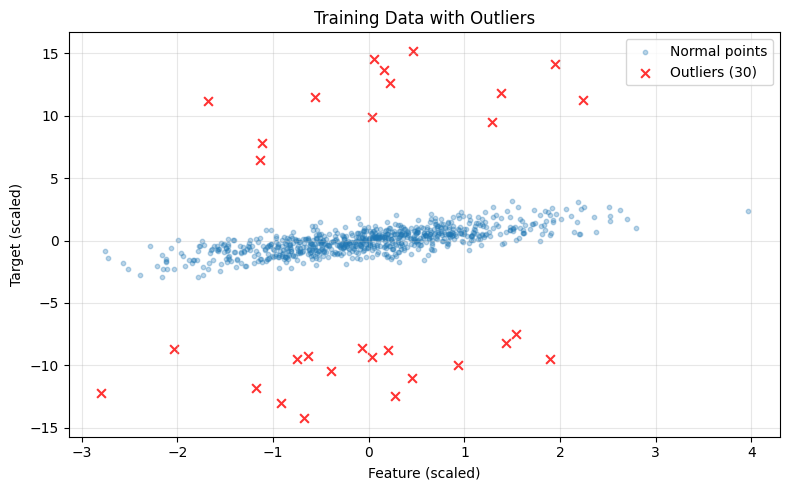

In [17]:
# Add outliers to training data
set_global_seed(42)
n_outliers = 30

# Create copies of training data
X_train_out = X_train_scaled.copy()
y_train_out = y_train_scaled.copy()

# Inject outliers: random indices get extreme y values
outlier_idx = np.random.choice(len(y_train_out), n_outliers, replace=False)
y_train_out[outlier_idx] += np.random.uniform(8, 15, n_outliers) * np.random.choice([-1, 1], n_outliers)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
mask = np.zeros(len(y_train_out), dtype=bool)
mask[outlier_idx] = True

ax.scatter(X_train_out[~mask, 0], y_train_out[~mask], alpha=0.3, s=10, label="Normal points")
ax.scatter(X_train_out[mask, 0], y_train_out[mask], alpha=0.8, s=40, c="red",
           marker="x", label=f"Outliers ({n_outliers})")
ax.set_xlabel("Feature (scaled)")
ax.set_ylabel("Target (scaled)")
ax.set_title("Training Data with Outliers")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Create loaders with outlier data
train_loader_out, test_loader_out = make_loaders(
    X_train_out, y_train_out, X_test_scaled, y_test_scaled
)

# Train with three different loss functions
losses = {
    "MSE": nn.MSELoss(),
    "MAE": nn.L1Loss(),
    "Huber": nn.HuberLoss(delta=1.0),
}

results = {}
models = {}

for name, loss_fn in losses.items():
    print(f"\n{'='*50}")
    print(f"Training with {name} Loss")
    print(f"{'='*50}")
    set_global_seed(42)
    model = RegressionMLP(input_dim=1).to(device)
    history = train_regression_model(
        model, train_loader_out, test_loader_out,
        loss_fn=loss_fn, lr=1e-3, epochs=100
    )
    results[name] = history
    models[name] = model


Training with MSE Loss
Epoch   1/100 | Train Loss: 5.7000 | Val Loss: 0.9232
Epoch  20/100 | Train Loss: 4.6707 | Val Loss: 0.5395
Epoch  40/100 | Train Loss: 4.8471 | Val Loss: 0.5448
Epoch  60/100 | Train Loss: 4.6464 | Val Loss: 0.5442
Epoch  80/100 | Train Loss: 5.0171 | Val Loss: 0.5480
Epoch 100/100 | Train Loss: 5.0591 | Val Loss: 0.5501

Training with MAE Loss
Epoch   1/100 | Train Loss: 1.1878 | Val Loss: 0.7569
Epoch  20/100 | Train Loss: 0.9030 | Val Loss: 0.5740
Epoch  40/100 | Train Loss: 0.9140 | Val Loss: 0.5758
Epoch  60/100 | Train Loss: 0.8966 | Val Loss: 0.5776
Epoch  80/100 | Train Loss: 0.9280 | Val Loss: 0.5776
Epoch 100/100 | Train Loss: 0.9308 | Val Loss: 0.5794

Training with Huber Loss
Epoch   1/100 | Train Loss: 0.8148 | Val Loss: 0.3965
Epoch  20/100 | Train Loss: 0.5758 | Val Loss: 0.2470
Epoch  40/100 | Train Loss: 0.5864 | Val Loss: 0.2459
Epoch  60/100 | Train Loss: 0.5710 | Val Loss: 0.2468
Epoch  80/100 | Train Loss: 0.6022 | Val Loss: 0.2466
Epoch 10

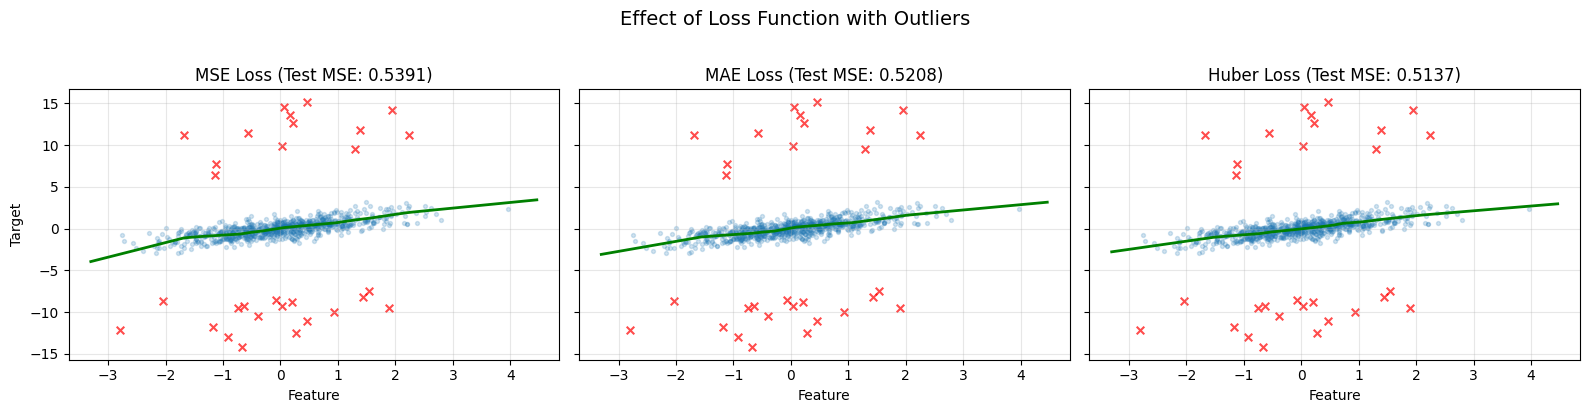

In [19]:
# Compare predictions on the grid
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    y_pred_grid = get_predictions(model, X_grid)
    y_pred_test = get_predictions(model, X_test_scaled)

    # Compute test MSE in original space for fair comparison
    test_mse = mean_squared_error(y_test_scaled, y_pred_test)

    ax.scatter(X_train_out[~mask, 0], y_train_out[~mask], alpha=0.2, s=8)
    ax.scatter(X_train_out[mask, 0], y_train_out[mask], alpha=0.7, s=30,
              c="red", marker="x")
    ax.plot(X_grid[:, 0], y_pred_grid, color="green", linewidth=2)
    ax.set_title(f"{name} Loss (Test MSE: {test_mse:.4f})")
    ax.set_xlabel("Feature")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Target")
plt.suptitle("Effect of Loss Function with Outliers", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**

- **MSE** is pulled toward outliers (large errors get squared, dominating the gradient)
- **MAE** is more robust but can have unstable gradients near zero error
- **Huber** gives the best of both: smooth gradients near zero, linear penalty for outliers

---

## 8. Training Curves Comparison

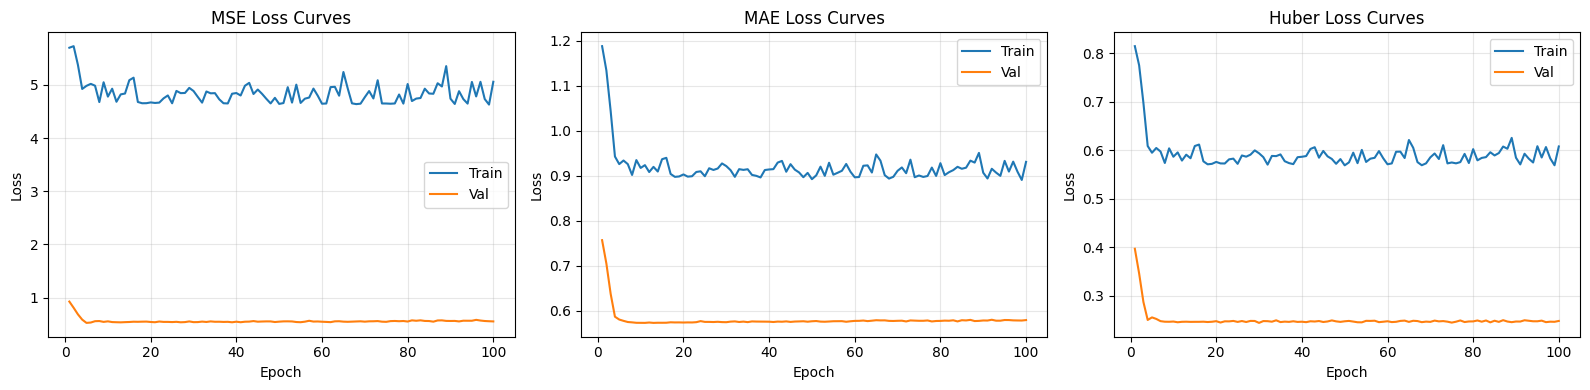

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, history) in zip(axes, results.items()):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], label="Train", linewidth=1.5)
    ax.plot(epochs, history["val_loss"], label="Val", linewidth=1.5)
    ax.set_title(f"{name} Loss Curves")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MSE    | Test MSE: 0.5391 | Test MAE: 0.5647 | R2: 0.4969
MAE    | Test MSE: 0.5208 | Test MAE: 0.5636 | R2: 0.5139
Huber  | Test MSE: 0.5137 | Test MAE: 0.5612 | R2: 0.5205


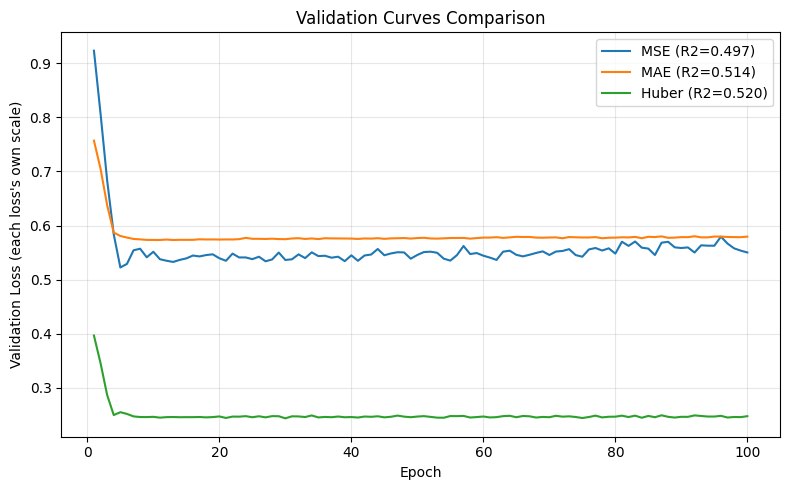

In [21]:
# All validation losses on one plot for direct comparison
# We evaluate all models with MSE for fair comparison
fig, ax = plt.subplots(figsize=(8, 5))

mse_fn = nn.MSELoss()
for name, model in models.items():
    y_pred = get_predictions(model, X_test_scaled)
    test_mse = mean_squared_error(y_test_scaled, y_pred)
    test_mae = mean_absolute_error(y_test_scaled, y_pred)
    test_r2 = r2_score(y_test_scaled, y_pred)

    val_losses = results[name]["val_loss"]
    ax.plot(range(1, len(val_losses) + 1), val_losses, label=f"{name} (R2={test_r2:.3f})")
    print(f"{name:6s} | Test MSE: {test_mse:.4f} | Test MAE: {test_mae:.4f} | R2: {test_r2:.4f}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss (each loss's own scale)")
ax.set_title("Validation Curves Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 9. Common Mistakes and Debugging Tips

| Mistake | Symptom | Fix |
|---------|---------|-----|
| Forgetting to call `model.train()` / `model.eval()` | Inconsistent losses, dropout active during eval | Always toggle mode |
| Not scaling targets | Very large MSE, unstable training | Standardize both X and y |
| Using sigmoid/softmax on regression output | Predictions stuck in [0,1] | No activation on output layer |
| Learning rate too high | Loss explodes or oscillates wildly | Start with 1e-3, decrease if unstable |
| Learning rate too low | Loss barely decreases | Increase LR or train more epochs |
| Not squeezing output tensor | Shape mismatch in loss function | Use `.squeeze(-1)` for regression |
| Forgetting `optimizer.zero_grad()` | Gradients accumulate, erratic training | Always zero gradients before `.backward()` |
| Data leakage in scaling | Optimistic test metrics | Fit scaler on train only, transform test |

---

## 10. Exercises

### Exercise 1: Architecture Exploration

Modify the `RegressionMLP` architecture and observe the effect:

1. Try a single hidden layer with 128 neurons
2. Try 4 hidden layers: `[128, 64, 32, 16]`
3. Try a very small network: `[8, 4]`

Which architecture works best? Why?

In [ ]:
# ===== EXERCISE 1: Your code here =====
# Try different architectures and compare

# architectures = {
#     "1 layer [128]": (128,),
#     "4 layers [128,64,32,16]": (128, 64, 32, 16),
#     "small [8,4]": (8, 4),
# }
#
# for name, hidden_dims in architectures.items():
#     set_global_seed(42)
#     model = RegressionMLP(input_dim=1, hidden_dims=hidden_dims).to(device)
#     history = train_regression_model(
#         model, train_loader, test_loader,
#         loss_fn=nn.MSELoss(), lr=1e-3, epochs=100, verbose=False
#     )
#     y_pred = get_predictions(model, X_test_scaled)
#     mse = mean_squared_error(y_test_scaled, y_pred)
#     print(f"{name:30s} | Test MSE: {mse:.4f}")

### Exercise 2: Learning Rate Sweep

Train the same model with learning rates `[1e-4, 5e-4, 1e-3, 5e-3, 1e-2]` and plot the training curves side by side.

In [ ]:
# ===== EXERCISE 2: Your code here =====
# learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
#
# fig, ax = plt.subplots(figsize=(8, 5))
# for lr in learning_rates:
#     set_global_seed(42)
#     model = RegressionMLP(input_dim=1).to(device)
#     history = train_regression_model(
#         model, train_loader, test_loader,
#         loss_fn=nn.MSELoss(), lr=lr, epochs=100, verbose=False
#     )
#     ax.plot(history["val_loss"], label=f"LR={lr}")
#
# ax.set_xlabel("Epoch")
# ax.set_ylabel("Validation Loss")
# ax.set_title("Learning Rate Comparison")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

### Exercise 1 -- Solution

In [ ]:
architectures = {
    "1 layer [128]": (128,),
    "4 layers [128,64,32,16]": (128, 64, 32, 16),
    "small [8,4]": (8, 4),
    "default [64,32,16]": (64, 32, 16),
}

fig, ax = plt.subplots(figsize=(8, 5))

for name, hidden_dims in architectures.items():
    set_global_seed(42)
    model = RegressionMLP(input_dim=1, hidden_dims=hidden_dims).to(device)
    history = train_regression_model(
        model, train_loader, test_loader,
        loss_fn=nn.MSELoss(), lr=1e-3, epochs=100, verbose=False
    )
    y_pred = get_predictions(model, X_test_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred)
    ax.plot(history["val_loss"], label=f"{name} (MSE={mse:.4f})")
    print(f"{name:30s} | Params: {sum(p.numel() for p in model.parameters()):,} | Test MSE: {mse:.4f}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Architecture Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFor this simple 1D problem, even a small network works well.")
print("Larger networks have more capacity but may take longer to converge.")

### Exercise 2 -- Solution

In [ ]:
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

fig, ax = plt.subplots(figsize=(8, 5))
for lr in learning_rates:
    set_global_seed(42)
    model = RegressionMLP(input_dim=1).to(device)
    history = train_regression_model(
        model, train_loader, test_loader,
        loss_fn=nn.MSELoss(), lr=lr, epochs=100, verbose=False
    )
    y_pred = get_predictions(model, X_test_scaled)
    mse = mean_squared_error(y_test_scaled, y_pred)
    ax.plot(history["val_loss"], label=f"LR={lr} (MSE={mse:.4f})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Learning Rate Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)  # clip for visibility
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Too small (1e-4): slow convergence, may not reach optimum in 100 epochs")
print("- Sweet spot (1e-3): fast convergence, stable")
print("- Too large (1e-2): may oscillate or diverge")

---

**Next notebook:** [02 -- MLP for Classification](02_MLP_for_Classification_MNIST_or_SklearnDigits.ipynb)